# Save precipitation data files that are spatially averaged over the VICWaCI regions

This is a draft.


Modified from: https://github.com/DamienIrving/VicWaCI/blob/master/agcd_monthly.ipynb

In [ ]:
import cartopy
import cartopy.crs as ccrs
from datetime import datetime
import geopandas as gp
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
import xclim

## Read precipitation data

In [ ]:
# Generate list of files (1980-2022 plus an extra month)
date_range = xr.date_range(
    f"1980-01-01", f"2023-01-31", freq="1MS"
)  # @todo: update clim period to full time
files = []
for dt in date_range:
    files_year = sorted(
        glob.glob(f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt.year}/tp_era5_oper_sfc_*.nc")
    )
    files.append(files_year)
files = np.concatenate(files)
files = files[:-11]  # Added an extra year, but only need the first timestep
files

array(['/g/data/rt52/era5/single-levels/reanalysis/tp/1980/tp_era5_oper_sfc_19800101-19800131.nc',
       '/g/data/rt52/era5/single-levels/reanalysis/tp/1980/tp_era5_oper_sfc_19800201-19800229.nc',
       '/g/data/rt52/era5/single-levels/reanalysis/tp/1980/tp_era5_oper_sfc_19800301-19800331.nc',
       ...,
       '/g/data/rt52/era5/single-levels/reanalysis/tp/2022/tp_era5_oper_sfc_20221101-20221130.nc',
       '/g/data/rt52/era5/single-levels/reanalysis/tp/2022/tp_era5_oper_sfc_20221201-20221231.nc',
       '/g/data/rt52/era5/single-levels/reanalysis/tp/2023/tp_era5_oper_sfc_20230101-20230131.nc'],
      shape=(6193,), dtype='<U88')

In [3]:
def preprocess(ds):
    """Preprocess the ERA5 dataset."""

    # Select only the "tp" variable (drops other variables like "lon_bnds", etc)
    ds = ds[["tp"]]

    # Select the region of interest (Victoria, Australia)
    # NB swap N/S for ERA5
    ds = ds.sel(latitude=slice(-33.5, -39.5), longitude=slice(140, 151))
    return ds


ds = xr.open_mfdataset(files, chunks="auto", preprocess=preprocess)
ds

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 377688, latitude: 25, longitude: 45)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1980-01-01 ... 2023-01-31T23:00:00
  * latitude   (latitude) float32 100B -33.5 -33.75 -34.0 ... -39.0 -39.25 -39.5
  * longitude  (longitude) float32 180B 140.0 140.2 140.5 ... 150.5 150.8 151.0
Data variables:
    tp         (time, latitude, longitude) float64 3GB dask.array<chunksize=(186, 25, 45), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-02 14:33:29 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 19800101-...

In [4]:
# Convert from m to mm
ds["tp"] *= 1e3
ds["tp"].attrs["units"] = "mm"

# Rename coords (avoids issues later)
ds = ds.rename({"latitude": "lat", "longitude": "lon"})
ds

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 377688, lat: 25, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1980-01-01 ... 2023-01-31T23:00:00
  * lat      (lat) float32 100B -33.5 -33.75 -34.0 -34.25 ... -39.0 -39.25 -39.5
  * lon      (lon) float32 180B 140.0 140.2 140.5 140.8 ... 150.5 150.8 151.0
Data variables:
    tp       (time, lat, lon) float64 3GB dask.array<chunksize=(186, 25, 45), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-02 14:33:29 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 19800101-...

In [5]:
# Calculate a single daily total manually (for testing)
tmp = ds.tp.isel(time=slice(1, None)).isel(time=slice(24)).sum("time")

In [6]:
# Ensure to exclude first processing step (records last hour of previous day) using 'end_day'
ds = ds.resample(time="24h", label="left", origin="end_day").sum("time")

# Remove before/after times that aren't based on full days
ds = ds.sel(time=slice("1980-01-01", "2022-12-31"))
ds

<xarray.Dataset> Size: 141MB
Dimensions:  (time: 15706, lat: 25, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 126kB 1980-01-01 1980-01-02 ... 2022-12-31
  * lat      (lat) float32 100B -33.5 -33.75 -34.0 -34.25 ... -39.0 -39.25 -39.5
  * lon      (lon) float32 180B 140.0 140.2 140.5 140.8 ... 150.5 150.8 151.0
Data variables:
    tp       (time, lat, lon) float64 141MB dask.array<chunksize=(8, 25, 45), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-02 14:33:29 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 19800101-...

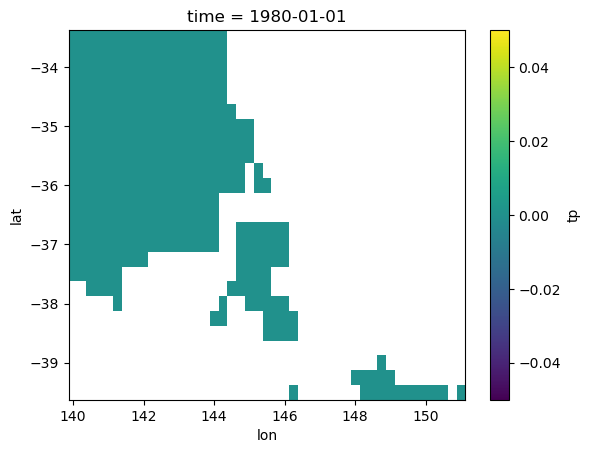

In [7]:
# Check this works as expected
diff = ds.tp.isel(time=0) - tmp
xr.where(ds.tp.isel(time=0), np.nan, diff).plot()

## Apply shapefiles to data

In [2]:
valid_regions = [
    "victoria",
    'north_east_victoria',
    'north_west_victoria',
    'south_east_victoria',
    'south_west_victoria',
]


def read_shapefile(region_name):
    assert region_name in valid_regions
    gdf = gp.read_file(f"/g/data/xv83/dbi599/vicwaci/shapefiles/{region_name}.shp")
    region = regionmask.from_geopandas(gdf)

    return region


def plot_frac(frac):
    fig = plt.figure(figsize=[8, 4])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    frac.plot(ax=ax, transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    plt.show()


def spatial_mean(ds, region_name, overlap_threshold=0.5):
    """Calculate spatial mean"""

    region = read_shapefile(region_name)
    frac = region.mask_3D_frac_approx(ds).isel(region=0)
    plot_frac(frac)

    weights = np.cos(np.deg2rad(ds["lat"]))
    spatial_mean = ds["tp"].weighted(frac * weights).mean(dim=("lat", "lon"))
    spatial_mean = np.round(spatial_mean, decimals=2)

    spatial_mean = spatial_mean.drop_vars(["region", "abbrevs", "names"])
    spatial_mean = spatial_mean.to_dataset()
    spatial_mean["time"].attrs = {
        "axis": "T",
        "standard_name": "time",
        "long_name": "time",
    }
    spatial_mean["tp"].attrs = {
        "units": "mm",
        "long_name": "spatial mean daily precipitation",
    }
    spatial_mean.attrs = {
        "summary": f"total daily precipitation averaged over the {region_name} region",
        "id": "ERA5",
        "license": ds.attrs["license"],
    }
    region_fname = region_name.replace("_", "-")
    outfile = f"/g/data/xv83/as3189/vicwaci/era5_tp_{region_fname}_1980-2022.nc"
    spatial_mean.attrs["history"] = (
        ds.attrs["history"]
        + f"\n{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} by era5_daily.ipynb: Created {outfile}"
    )

    spatial_mean.to_netcdf(
        outfile,
        compute=True,
        encoding={
            "time": {"_FillValue": None},
            "tp": {"_FillValue": None, "zlib": True, "complevel": 4, "shuffle": True},
        },
    )
    spatial_mean.close()

    print(outfile)

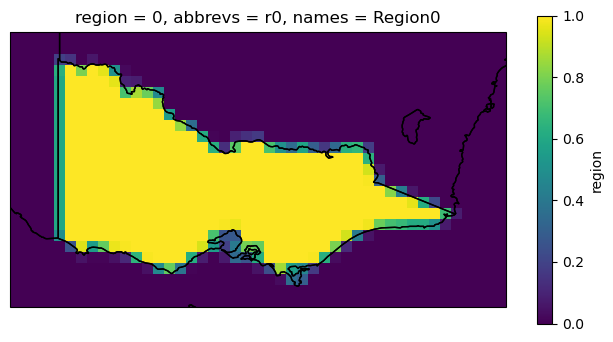

/g/data/xv83/as3189/vicwaci/era5_tp_victoria_1980-2022.nc


In [9]:
for region in valid_regions:
    spatial_mean(ds, region)

# Calculate terciles

In [ ]:
region_fname = "victoria"
ds = xr.open_dataset(f"/g/data/xv83/as3189/vicwaci/era5_tp_{region_fname}_1980-2022.nc")
ds

<xarray.Dataset> Size: 251kB
Dimensions:  (time: 15706)
Coordinates:
  * time     (time) datetime64[ns] 126kB 1980-01-01 1980-01-02 ... 2022-12-31
Data variables:
    tp       (time) float64 126kB ...
Attributes:
    summary:  total daily precipitation averaged over the victoria region
    id:       ERA5
    license:  Licence to use Copernicus Products: https://apps.ecmwf.int/data...
    history:  2023-09-02 14:33:29 UTC+1000 by era5_replication_tools-1.12.0: ...

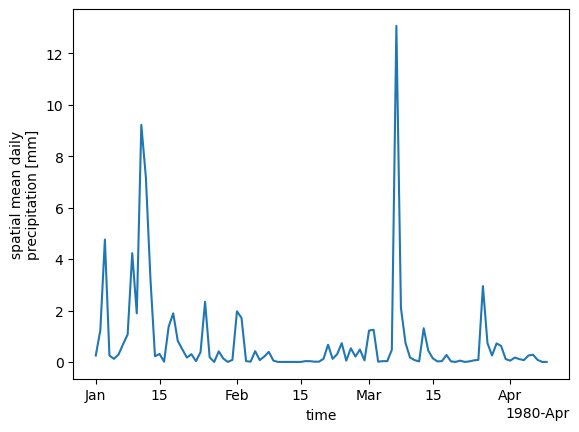

In [51]:
ds.isel(time=slice(100)).tp.plot()

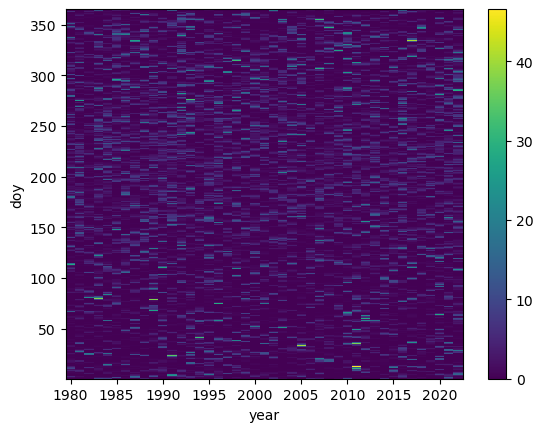

In [ ]:
g = ds.tp.groupby("time.dayofyear").groups
doy = np.arange(1, 366)
years = np.unique(ds.time.dt.year)
a = np.vstack([ds.tp.isel(time=g[i]) for i in doy])
a = xr.DataArray(a, dims=("doy", "year"), coords=dict(doy=doy, year=years))
a.plot()

In [ ]:
ds = ds.resample(time="MS").sum()
da = ds.tp

In [88]:
q = 3
print(np.arange(q + 1) / q)
bins = da.groupby("time.month").quantile(np.arange(q + 1) / q)
bins

[0.         0.33333333 0.66666667 1.        ]


<xarray.DataArray 'tp' (month: 12, quantile: 4)> Size: 384B
array([[0.30548387, 1.05354839, 1.58354839, 4.06709677],
       [0.28310345, 0.86464286, 1.51642857, 4.42428571],
       [0.37677419, 0.87096774, 1.56      , 4.35129032],
       [0.344     , 1.05833333, 1.68233333, 3.54366667],
       [0.28709677, 1.35870968, 1.93387097, 3.13258065],
       [0.38233333, 1.50866667, 2.15533333, 4.542     ],
       [0.71354839, 1.71451613, 2.13032258, 3.33322581],
       [0.56258065, 1.83612903, 2.51580645, 3.58548387],
       [0.829     , 1.64      , 2.605     , 4.99733333],
       [0.31774194, 1.47903226, 2.57677419, 6.05709677],
       [0.45733333, 1.67666667, 2.301     , 3.728     ],
       [0.37258065, 1.30064516, 2.21645161, 4.09967742]])
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * quantile  (quantile) float64 32B 0.0 0.3333 0.6667 1.0
Attributes:
    units:      mm
    long_name:  spatial mean daily precipitation

In [ ]:
q = 3


def _bin_month(group):
    bins = group.quantile(np.arange(q + 1) / q)

    # Use pd.cut to label the data
    labels = pd.cut(group.values, bins=bins, labels=[1, 2, 3], include_lowest=True)

    # Return a new DataArray matching the group's structure
    return xr.DataArray(labels, coords=group.coords, dims=group.dims)


dx = da.groupby("time.month").map(_bin_month)

dx

<xarray.DataArray (time: 516)> Size: 540B
[2, 1, 1, 3, 2, ..., 3, 3, 3, 3, 2]
Length: 516
Categories (3, int64): [1 < 2 < 3]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2022-12-01

<BarContainer object of 100 artists>

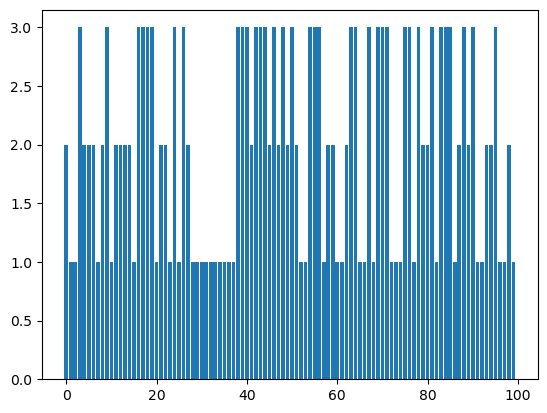

In [90]:
dx = xr.DataArray(dx.values, coords=da.coords, dims=da.dims)
plt.bar(np.arange(100), dx.isel(time=slice(100)))

In [ ]:
data = dx
mask = xclim.indices.generic.spell_mask(
    dx, 3, "min", "==", 3, min_gap=0, weights=None, var_reducer="all"
)
mask

<xarray.DataArray (time: 516)> Size: 516B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True, False,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True, False])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2022-12-01

(0.0, 516.0)

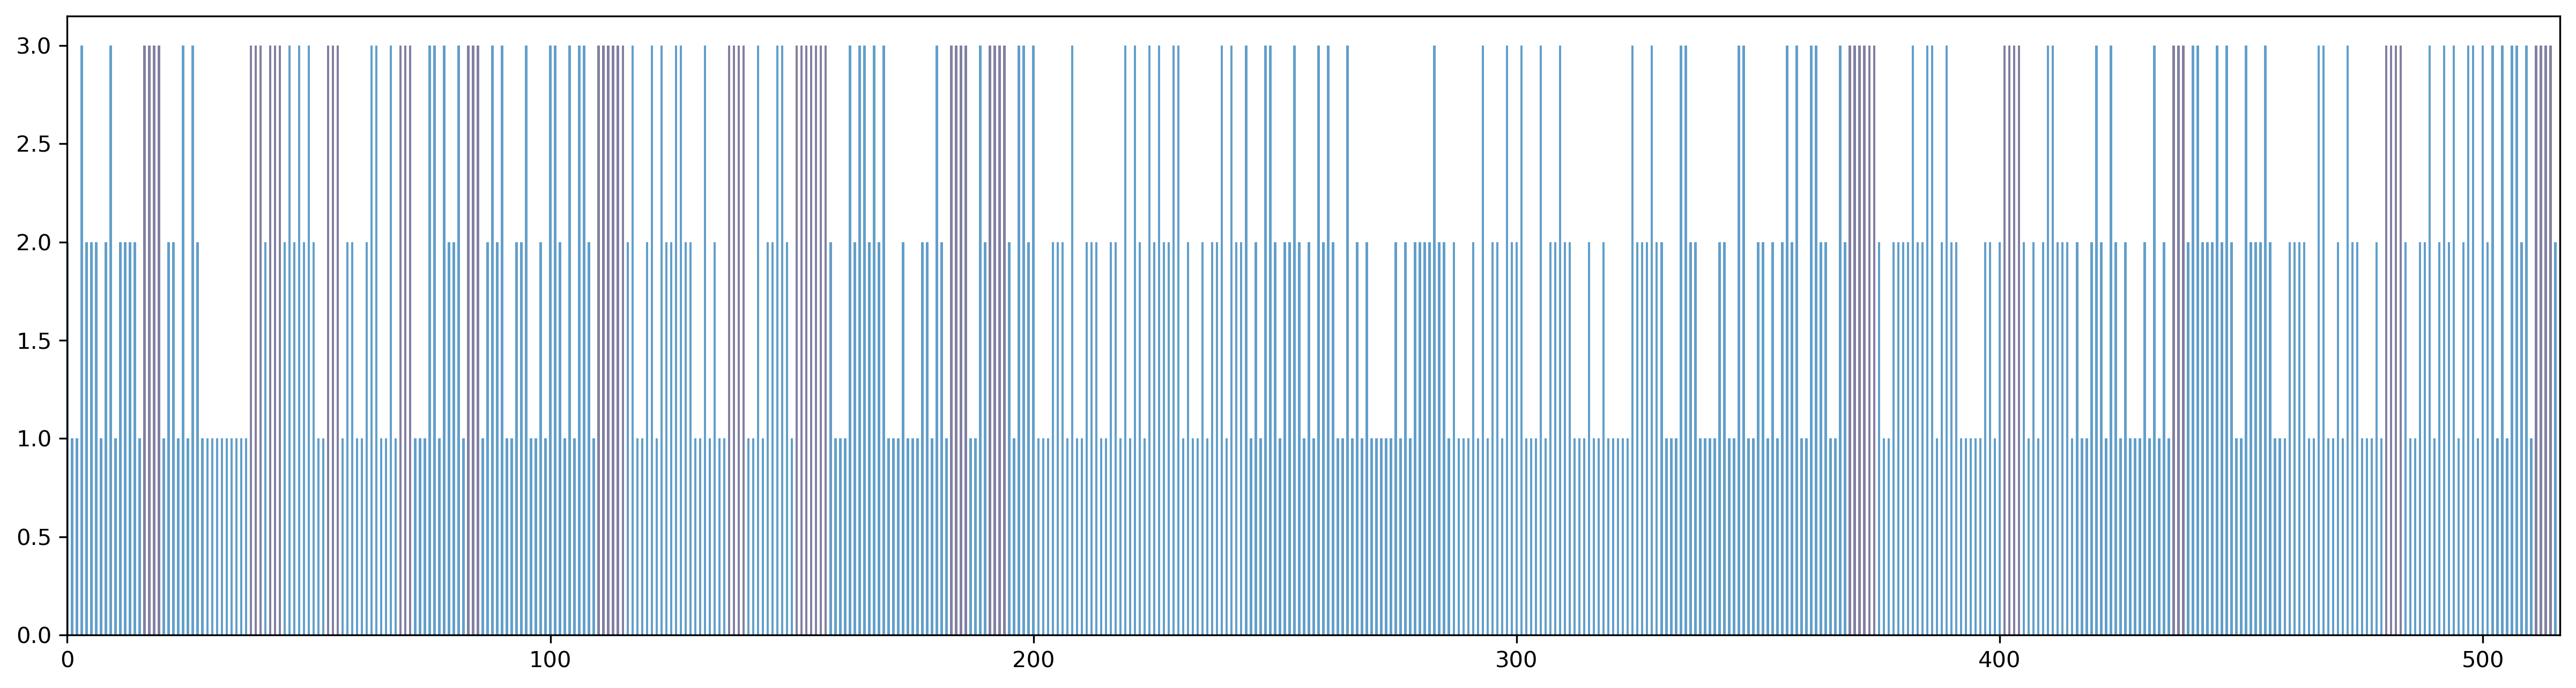

In [ ]:
fig, ax = plt.subplots(figsize=(20, 5), dpi=300)
t = np.arange(dx.time.size)
ax.bar(t, dx, alpha=0.7, width=0.5)
tt = dx.time[mask]
ax.bar(t[mask], dx.sel(time=tt), color="r", alpha=0.2, width=0.5)
ax.set_xlim(0, 516)

In [93]:
mask_condition = dx == 3
mask_condition

<xarray.DataArray (time: 516)> Size: 516B
array([False, False, False,  True, False, False, False, False, False,
        True, False, False, False, False, False, False,  True,  True,
        True,  True, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True, False,  True,  True,  True,
       False,  True, False,  True, False,  True, False, False, False,
        True,  True,  True, False, False, False, False, False, False,
        True,  True, False, False,  True, False,  True,  True,  True,
       False, False, False,  True,  True, False,  True, False, False,
        True, False,  True,  True,  True, False, False,  True, False,
        True, False, False, False, False,  True, False, False, False,
       False,  True,  True, False, False,  True, False,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True, False,
        True, False, False, False,  True, False,  True, False, False,
        True,  True, False, False, False, False,  True, False, False,
       False, False,  True,  True,  True,  True, False, False,  True,
       False, False, False,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
        True, False,  True,  True, False,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False,  True, False,  True, False,
       False,  True,  True, False, False, False, False,  True, False,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False, False, False, False, False, False,
        True, False, False, False,  True,  True,  True, False,  True,
        True, False, False, False,  True, False,  True, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False, False, False,  True, False, False, False, False,
       False, False, False,  True,  True,  True,  True, False, False,
       False, False, False,  True, False, False,  True, False,  True,
       False, False,  True,  True, False,  True, False,  True, False,
        True, False,  True,  True, False,  True, False,  True,  True,
        True,  True, False])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2022-12-01

In [ ]:
run_lengths = xclim.indices.run_length.rle_statistics(
    da=mask_condition,
    reducer="max",
    window=3,
    freq=None,
)

mask = run_lengths >= 3

# 4. Apply the mask to your original DataArray
# This drops all elements that are not part of a qualifying spell
masked_da = da.where(mask)
masked_da

<xarray.DataArray 'tp' (time: 516)> Size: 4kB
array([1.40483871, 0.28310345, 0.87096774, 2.211     , 1.56806452,
       2.15533333, 2.04129032, 1.76612903, 1.878     , 3.0116129 ,
       1.50166667, 2.21645161, 1.48      , 0.96464286, 1.20354839,
       0.361     , 2.50935484, 3.12833333, 3.33322581, 3.38      ,
       1.478     , 1.92806452, 1.97533333, 1.29451613, 1.6416129 ,
       0.28535714, 2.24935484, 1.066     , 1.35870968, 0.993     ,
       0.71354839, 0.56258065, 1.47466667, 0.93645161, 0.45733333,
       1.17483871, 0.90387097, 0.48535714, 3.07064516, 2.25833333,
       2.80935484, 1.549     , 2.48516129, 2.52806452, 3.27166667,
       2.28      , 2.955     , 2.09548387, 2.52806452, 1.09862069,
       1.81225806, 1.42733333, 0.97      , 0.74133333, 2.84419355,
       3.58548387, 2.98266667, 1.46935484, 1.80866667, 1.36419355,
       0.72709677, 0.45464286, 1.41645161, 1.86433333, 2.07096774,
       1.50733333, 1.34096774, 3.2216129 , 1.53033333, 3.06935484,
       2.59333333, 3.78645161, 0.86612903, 0.72607143, 0.37677419,
       1.81666667, 2.37387097, 1.33633333, 3.30032258, 2.51580645,
       2.34233333, 3.90741935, 1.67666667, 2.80580645, 1.63290323,
       1.89178571, 0.79967742, 1.081     , 2.35      , 1.937     ,
       2.23      , 1.65129032, 0.99433333, 1.73451613, 2.17166667,
       2.80741935, 0.79741935, 0.52344828, 1.15774194, 1.05033333,
...
       2.34451613, 1.13357143, 0.43483871, 2.202     , 1.55516129,
       1.15933333, 1.97258065, 1.59322581, 1.187     , 0.86903226,
       1.88333333, 0.91903226, 2.44387097, 0.36931034, 1.22774194,
       1.05833333, 2.39774194, 2.82333333, 2.94935484, 2.36806452,
       4.99733333, 2.68354839, 1.746     , 1.71483871, 1.23612903,
       1.60178571, 1.41516129, 2.53633333, 1.53806452, 0.38233333,
       1.6416129 , 2.58967742, 1.85433333, 1.94290323, 2.13166667,
       2.63483871, 1.27806452, 0.56464286, 0.56516129, 0.63      ,
       1.83451613, 1.602     , 1.73032258, 2.13548387, 0.829     ,
       1.24032258, 2.34133333, 2.72451613, 0.38322581, 0.8075    ,
       1.00741935, 0.56633333, 2.72032258, 1.891     , 1.82451613,
       1.74193548, 1.601     , 1.09387097, 1.97033333, 0.37258065,
       1.94387097, 1.89931034, 1.56419355, 3.54366667, 1.67870968,
       1.208     , 1.35      , 2.41225806, 2.158     , 3.50129032,
       1.53133333, 1.51483871, 2.46064516, 1.25321429, 1.58677419,
       0.63666667, 1.74935484, 2.66566667, 2.57354839, 1.49193548,
       2.89233333, 2.29806452, 3.12166667, 1.19806452, 3.06225806,
       0.86464286, 1.68774194, 2.44566667, 1.72225806, 2.168     ,
       1.49483871, 3.23741935, 3.21966667, 6.05709677, 3.427     ,
       1.63709677])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2022-12-01
Attributes:
    units:      mm
    long_name:  spatial mean daily precipitation